In [1]:
import sys
print(sys.executable)

d:\task1\venv\Scripts\python.exe


In [2]:
import numpy as np
print(np.__version__)

1.26.4


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os
print(os.getcwd())

d:\task1\notebook


In [7]:
df = pd.read_csv(r"D:\task1\dataset\housing_data.csv")

In [8]:
df.head()

,country,iso,year,house_price_index,personal_disposable_income,real_house_price_index,real_personal_disposable_income,affordability_proxy
0,Australia,AUS,1975,2.83,7.19,21.89,55.72,39.29
1,Australia,AUS,1976,3.19,8.11,21.65,55.04,39.34
2,Australia,AUS,1977,3.48,8.91,21.43,54.88,39.05
3,Australia,AUS,1978,3.75,9.85,21.28,55.91,38.06
4,Australia,AUS,1979,4.20,10.80,21.75,55.94,38.88


In [9]:
df.shape

(1326, 8)

In [10]:
df.columns

Index(['country', 'iso', 'year', 'house_price_index',
       'personal_disposable_income', 'real_house_price_index',
       'real_personal_disposable_income', 'affordability_proxy'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1326 entries, 0 to 1325
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          1326 non-null   object 
 1   iso                              1326 non-null   object 
 2   year                             1326 non-null   int64  
 3   house_price_index                1326 non-null   float64
 4   personal_disposable_income       1326 non-null   float64
 5   real_house_price_index           1326 non-null   float64
 6   real_personal_disposable_income  1326 non-null   float64
 7   affordability_proxy              1326 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 83.0+ KB


In [12]:
df.isnull().sum()

country                            0
iso                                0
year                               0
house_price_index                  0
personal_disposable_income         0
real_house_price_index             0
real_personal_disposable_income    0
affordability_proxy                0
dtype: int64

In [15]:
df.duplicated().sum()

0

In [17]:
df.dtypes

country                             object
iso                                 object
year                                 int64
house_price_index                  float64
personal_disposable_income         float64
real_house_price_index             float64
real_personal_disposable_income    float64
affordability_proxy                float64
dtype: object

In [18]:
df["year"] = df["year"].astype(int)

In [19]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

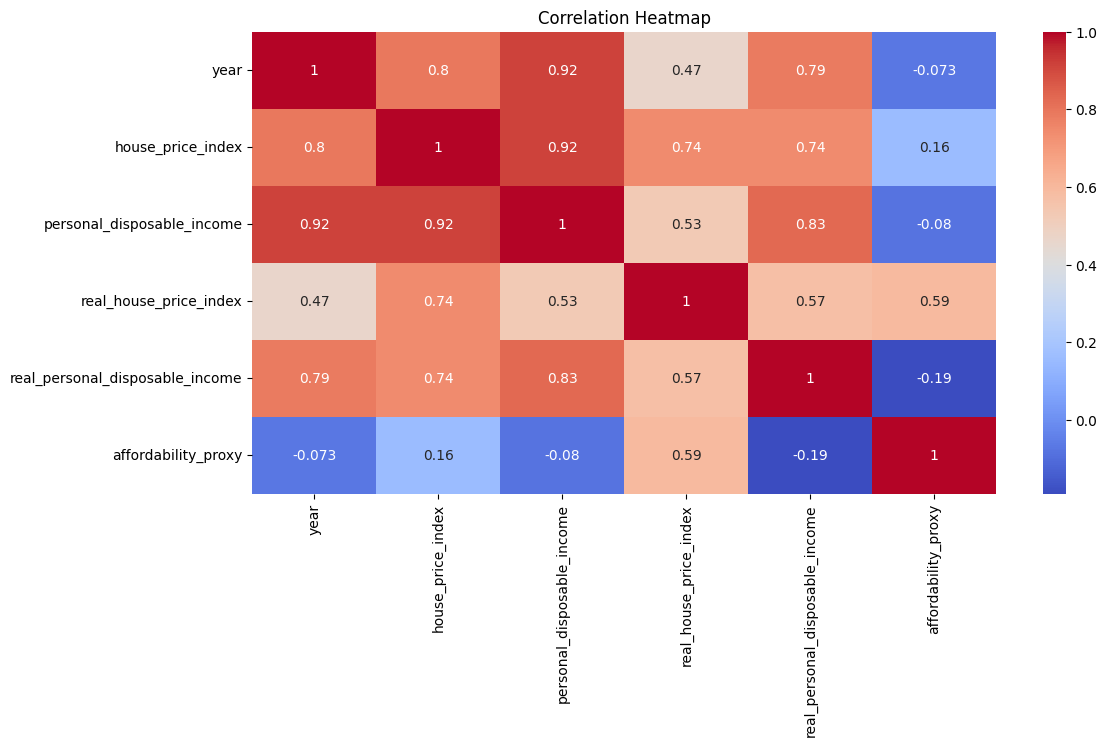

In [20]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

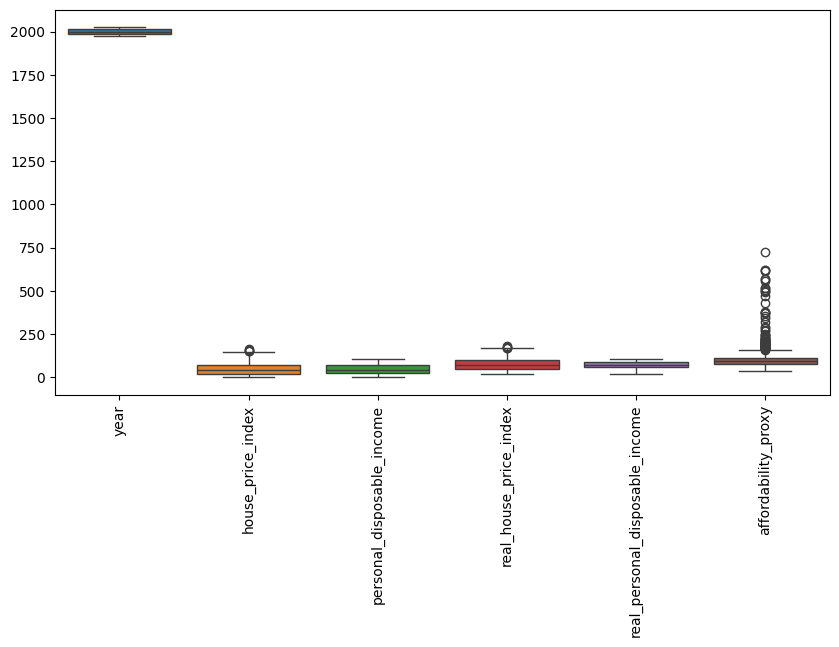

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

In [22]:
Q1 = df.select_dtypes(include=np.number).quantile(0.25)
Q3 = df.select_dtypes(include=np.number).quantile(0.75)

IQR = Q3 - Q1

df = df[~((df.select_dtypes(include=np.number) < (Q1 - 1.5 * IQR)) |
          (df.select_dtypes(include=np.number) > (Q3 + 1.5 * IQR))).any(axis=1)]

In [23]:
df.to_csv(r"D:\task1\dataset\cleaned_housing_data.csv", index=False)

In [24]:
df.head()

,country,iso,year,house_price_index,personal_disposable_income,real_house_price_index,real_personal_disposable_income,affordability_proxy
0,Australia,AUS,1975,2.83,7.19,21.89,55.72,39.29
1,Australia,AUS,1976,3.19,8.11,21.65,55.04,39.34
2,Australia,AUS,1977,3.48,8.91,21.43,54.88,39.05
3,Australia,AUS,1978,3.75,9.85,21.28,55.91,38.06
4,Australia,AUS,1979,4.20,10.80,21.75,55.94,38.88
